In [1]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
from cartopy import crs as ccrs
import geopandas as gpd
import contextily as ctx
plt.rcParams['font.family'] = 'Times New Roman,Microsoft YaHei'  
plt.rcParams['mathtext.fontset'] = 'stix'  # 设置数学公式字体为stix
from sklearn import preprocessing
import numpy as np
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from matplotlib.lines import Line2D

In [2]:
data1=pd.read_csv('basic_var.csv')
data2=pd.read_csv('music_var_chordkey.csv')
data3=pd.read_csv('soundfeature_other.csv')
data = pd.merge(data1,data2 ,on=['file'], how='left', suffixes=('', '_drop'))
data = data[[col for col in data.columns if not col.endswith('_drop')]]
data = pd.merge(data,data3 ,on=['file'], how='left', suffixes=('', '_drop'))
data = data[[col for col in data.columns if not col.endswith('_drop')]]
data =data.loc[:, ~data.columns.duplicated()]
data['chord'] = data['chord'].str.strip('{}').str.split(',')

In [3]:
data

,Unnamed: 0,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,lat,...,EVNspMean,EVNspCount,TFSD,H_Havrda,H_Renyi,H_gamma,H_GiniSimpson,AGI,ROItotal,ROIcover
0,0,2022-01-16 00:00:00,Eurasian Teal,Anas crecca,XC706499.mp3,XC706499,Irish Wildlife Sounds,Ireland,"Tacumshane, Wexford, County Wexford",52.1853,...,0.050250,0.237873,0.000000,0.323276,1.750406,342.933459,0.846384,1.763521,144.0,3.166691
1,1,2023-12-13 10:03:00,Eurasian Teal,Anas crecca,XC872164.mp3,XC872164,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.020933,0.159533,0.478084,0.331455,2.589358,35582.846346,0.942238,1.263552,73.0,3.437754
2,2,2024-11-04 08:11:00,Eurasian Teal,Anas crecca,XC946313.mp3,XC946313,Sonothèque ADVL,France,"Cabane Vauban (Carolles), Manche, Normandie",48.7443,...,0.027326,0.492219,0.364335,0.329500,2.232644,4023.734559,0.916002,1.307255,128.0,9.873588
3,3,2014-07-13 09:00:00,Eurasian Teal,Anas crecca,XC187090.mp3,XC187090,Albert Lastukhin,Russian Federation,"Novocheboksarsk, gorod Novocheboksarsk, Chuvas...",56.1056,...,0.057078,0.361062,0.460048,0.333260,4.210168,24701.050359,0.987338,1.420083,267.0,5.509801
4,4,2023-12-18 15:03:00,Eurasian Teal,Anas crecca,XC872174.mp3,XC872174,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.037341,0.188268,0.476359,0.332782,3.201939,38474.387121,0.972857,1.285792,161.0,4.207794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,14620,2020-10-04 21:05:00,Greater White-fronted Goose,Anser albifrons,XC592979.mp3,XC592979,Juha Saari,Finland,"Pihlajamäki, Helsinki, Uusimaa",60.2357,...,0.077633,0.652936,0.000000,0.332714,3.144461,6733.278040,0.967246,2.038239,278.0,13.252572
14621,14621,2022-10-02 22:00:00,Greater White-fronted Goose,Anser albifrons,XC753535.mp3,XC753535,Uku Paal,Estonia,"Tartu, Tartu City, Tartu maakond",58.3752,...,0.044391,0.222631,0.000000,0.332871,3.289931,10339.811767,0.968750,1.265332,397.0,4.669571
14622,14622,2008-02-17 19:05:00,Greater White-fronted Goose,Anser albifrons,XC280889.mp3,XC280889,Peter Boesman,Belgium,"Uitkerkse polders, West-Vlaanderen",51.2950,...,0.081556,2.182158,0.000000,0.330864,2.452579,880.761415,0.924076,4.589344,89.0,4.272296
14623,14623,2021-11-23 01:36:00,Greater White-fronted Goose,Anser albifrons,XC718649.mp3,XC718649,Chèvremont Fabian,Belgium,"Fléron, Liège, Wallonie",50.6041,...,0.046229,0.257331,0.387644,0.331772,2.681686,16106.852922,0.948817,1.245774,110.0,1.291541


In [4]:
data.rename(columns={'lat': 'latitude', 'lng': 'longitude', 'Unnamed: 0': 'id'}, inplace=True)
# # 初始化地理编码器
# geolocator = Nominatim(user_agent="geo_lookup")
# # 定义函数来获取坐标
# def get_coordinates(location):
#     try:
#         loc = geolocator.geocode(location, timeout=10)
#         if loc:
#             return loc.latitude, loc.longitude
#     except GeocoderTimedOut:
#         return None, None
#     return None, None
# 
# # 找出缺失坐标的行
# missing_coords = data[data[['latitude', 'longitude']].isna().any(axis=1)].copy()
# # 通过地点信息补充坐标
# for idx, row in missing_coords.iterrows():
#     if pd.notna(row['loc']):
#         lat, lon = get_coordinates(row['loc'])
#         if lat and lon:
#             data.at[idx, 'latitude'] = lat
#             data.at[idx, 'longitude'] = lon

In [5]:
# 栖息地分类映射
habitat_mapping = {
    'Aquatic and Wetland Surface Birds': ['Eurasian Wigeon', 'Tundra Swan', 'Mallard', 
                                          'Greater White-fronted Goose', 'Common Goldeneye', 
                                          'Green-winged Teal', 'Eurasian Coot', 'Eurasian Moorhen','Common Moorhen','Eurasian Teal'],

    'Shoreline and Marsh Birds': ['Eurasian Curlew', 'Whimbrel','Eurasian Whimbrel'],

    'Grassland Ground Birds': ['Olive-backed Pipit', 'Yellow-browed Bunting', 'Yellow-billed Grosbeak'],

    'Shrub Layer Birds': ['Light-vented Bulbul', 'Chinese Hwamei', 'Japanese Tit', 
                          'Silver-throated Tit', 'Chinese Blackbird', 'Pale-legged Leaf Warbler','Silver-throated Bushtit'],

    'Lower Canopy Birds': ['Pale Thrush', 'Oriental Magpie'],

    'Upper Canopy and Aerial Birds': ["Swinhoe's White-eye"]
}
# 将所有物种映射到栖息地类别
species_to_habitat = {}
for habitat, species_list in habitat_mapping.items():
    for species in species_list:
        species_to_habitat[species] = habitat
# 分类函数
def classify_bird_habitat(species):
    return species_to_habitat.get(species, 'Other')  # 若未匹配到则归类为 'Other'

bird_name_mapping = {
    'Eurasian Teal': 'Eurasian Moorhen',
    'Silver-throated Bushtit': 'Silver-throated Tit',
    'Common Moorhen': 'Eurasian Moorhen', 
    'Eurasian Whimbrel': 'Whimbrel'  
}
# 先转换 `birdenname`
data['bird'] = data['birdenname'].replace(bird_name_mapping)

# 应用分类函数
data['habitat'] = data['bird'].copy().apply(classify_bird_habitat)

# 应用分类函数
data['habitat'] = data['birdenname'].copy().apply(classify_bird_habitat)

# 根据分类映射顺序创建分类类型
habitat_order = list(habitat_mapping.keys())
data['habitat'] = pd.Categorical(data['habitat'], categories=habitat_order, ordered=True)

In [6]:

gdf = geopandas.GeoDataFrame(
    data, geometry=geopandas.points_from_xy(data.longitude, data.latitude))
# 替换为你本地存储的 .shp 文件路径
shapefile_path = "ne_110m_admin_0_countries.shp"
# 读取世界地图数据
world = gpd.read_file(shapefile_path)
df = world 
df = df[df["CONTINENT"] != "Antarctica"]  # 移除南极洲

In [7]:
gdf.crs = 'WGS84'

In [8]:
# **确保 CRS 统一**
gdf = gdf.set_crs("EPSG:4326")  # WGS84 经纬度
df = df.to_crs(gdf.crs)
# **匹配国家**
gdf = gpd.sjoin(gdf, df[['ADMIN', 'geometry']], how="left", predicate="within")
# **去掉多余列**
gdf = gdf.drop(columns=['index_right'], errors='ignore')
# **统计每个国家的样本点数量**
country_counts = gdf.groupby("ADMIN").size().reset_index(name="count")
# **合并到 df**
df = df.merge(country_counts, on="ADMIN", how="left").fillna(0)

C:\Users\aa271\AppData\Local\Temp\ipykernel_25116\3665002391.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.merge(country_counts, on="ADMIN", how="left").fillna(0)


In [9]:
continents = df.dissolve(by="CONTINENT").reset_index()
# **确保 CRS 一致**
gdf = gdf.set_crs("EPSG:4326")  # WGS84 地理坐标
continents = continents.to_crs(gdf.crs)
# **使用空间连接，为每个点找到所在的洲**
gdf = gpd.sjoin(gdf, continents[['CONTINENT', 'geometry']], how="left", predicate="within")

# 获取洲的中心点
continents['centroid'] = continents.geometry.centroid

C:\Users\aa271\AppData\Local\Temp\ipykernel_25116\2248707841.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  continents['centroid'] = continents.geometry.centroid


In [10]:
from collections import Counter
# 存储绘图数据
pie_data = {}
crs = ccrs.Robinson()
# 统计每个洲的和弦数据（只绘制样本点≥10的洲）
for continent, group in gdf.groupby('CONTINENT'):
    if len(group) >= 10:  # 仅处理样本点数量 ≥ 10 的洲
        all_chords = [chord for chords in group['chord'].dropna() for chord in chords]
        chord_counts = Counter(all_chords)  # 统计和弦频率
        top_5_chords = chord_counts.most_common(12)  # 取前5个

        # 计算占比
        total = sum(chord_counts.values())
        labels, values = zip(*top_5_chords) if top_5_chords else ([], [])
        percentages = [v / total for v in values] if total > 0 else []

        # **转换坐标到投影**
        centroid = continents.loc[continents['CONTINENT'] == continent, 'centroid'].values[0]
        lon, lat = centroid.x, centroid.y
        if continent == "Europe":
            lon -= 45
        lon_proj, lat_proj = crs.transform_point(lon, lat, ccrs.PlateCarree())

        # 存储数据（投影坐标，labels，values）
        pie_data[continent] = (lon_proj, lat_proj, labels, percentages)

# **计算各洲的数据点数量**
continent_sizes = {continent: len(group) for continent, group in gdf.groupby('CONTINENT')}

In [11]:
# import matplotlib.patheffects as path_effects
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# 
# def plot_pie_inset(data, labels, lon, lat, ax, width, fontsize=15):
#     """
#     在地图上插入 Pie Chart，并标注类别名称
# 
#     参数：
#     - data: Pie Chart 数据（百分比）
#     - labels: 和弦名称
#     - lon, lat: Pie Chart 的投影坐标
#     - ax: Matplotlib 轴
#     - width: Pie Chart 的大小（归一化）
#     - fontsize: 文字大小（默认 12）
#     """
#     if sum(data) == 0:
#         return  # **跳过空 Pie Chart**
# 
#     # **指定颜色**
#     pie_colors = ["#48A9C5", "#009F4D", "#FE5000", "#EFDF00", "#A51890"]
# 
#     # **创建 inset_axes**
#     ax_sub = inset_axes(ax, width=width, height=width, loc=10, 
#                         bbox_to_anchor=(lon, lat),
#                         bbox_transform=ax.transData, borderpad=0)
#     
#     # **绘制 Pie Chart**
#     wedges, texts, autotexts = ax_sub.pie(
#         data, labels=labels, autopct='%1.1f%%', startangle=90,
#         colors=pie_colors[:len(data)], textprops={'fontsize': fontsize, 'weight': 'bold', 'color': 'black'},  
#     pctdistance=0.75
#     )
#     
#     # **调整百分比文本字体大小**
#     for autotext in autotexts:
#         autotext.set_fontsize(10)  # **减小百分比字体**
# 
#     # **为文本添加白色描边**
#     for text in texts + autotexts:
#         text.set_path_effects([
#             path_effects.Stroke(linewidth=2, foreground='white'),  # **白色描边**
#             path_effects.Normal()
#         ])
#         
#     
#     ax_sub.set_aspect("equal")  # **保持 Pie Chart 形状不变**

In [12]:
crs = ccrs.Robinson()
# **设置坐标系为 WGS84 并转换为 Robinson**
continents = continents.to_crs("EPSG:4326")  # **确保 WGS84**
continents = continents.to_crs(crs.proj4_init)  # **转换到 Robinson 投影**
# **确保 `gdf` 和 `continents` 坐标一致**
gdf = gdf.set_crs("EPSG:4326")  
gdf = gdf.to_crs(crs.proj4_init)  # **转换到 Robinson**
df = df.set_crs("EPSG:4326")  
df = df.to_crs(crs.proj4_init)  # **转换到 Robinson**
world = world.set_crs("EPSG:4326")
world = world.to_crs(gdf.crs)  # **转换 world 到相同 CRS**

In [13]:
from matplotlib.colors import Normalize
from palettable.cmocean.sequential import Dense_4, Amp_16
from matplotlib.colors import ListedColormap
# 限制颜色范围到5%-85%
def truncated_cmap(cmap, minval=0.05, maxval=0.85, n=100):
    new_cmap = ListedColormap(cmap(np.linspace(minval, maxval, n)))
    return new_cmap
norm = Normalize(vmin=np.log(df["count"].min()+1), vmax=np.log(df["count"].max()))  # 归一化
# 设置颜色映射
country_cmap = truncated_cmap(Amp_16.mpl_colormap, 0, 0.7)

In [14]:
from matplotlib.offsetbox import AnnotationBbox, OffsetBox
import io
import matplotlib.patheffects as path_effects
import cairosvg

chroma_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
minor_chords = [s + 'm' for s in chroma_labels]  # 小三和弦
major_chords = chroma_labels  # 大三和弦
chord_labels = major_chords + minor_chords  # 共24个和弦
def plot_radarbar_inset(
    data, 
    labels, 
    lon, 
    lat, 
    ax, 
    width=1.0, 
    fontsize=12,
    max_radius=10.0,
    inner_radius=5.0,
    bar_color_major="#ee6123",
    bar_color_minor="#61b3de",
    show_text=True,
        zoom=0.3,addin=True
):
    """
    在“内存”中绘制一个雷达柱状图 (Radial Bar Chart) 并保存为 SVG，
    然后将其贴到地图坐标轴 ax 上 (lon, lat) 位置。

    参数：
    ----------
    data: array-like
        需要绘制的数值（可理解为柱子的高度）。
        例如 array([0.0989011, 0.07692308, ... , 0.03296703])
    labels: list/tuple
        每个柱子的标签（如和弦名称）。
        例如 ('A#m', 'Cm', 'Dm', ..., 'F')
    lon, lat: float
        柱状图插入位置在 ax 的投影坐标（注意：需与 ax.crs 匹配或已转换）。
    ax: matplotlib.axes
        主图上的坐标轴（地图）对象。
    width: float
        显示在地图上的“缩放因子”，类似对最终贴图进行再缩放。
    fontsize: int
        文字大小。
    max_radius: float
        控制极坐标图的最外半径（可按你数据适当调整）。
    inner_radius: float
        柱子起始的“空心”半径，相当于离圆心的最小距离。
    bar_color_major, bar_color_minor: str
        两种柱子的配色，随需求自行修改。
    show_text: bool
        是否显示柱子顶部的文字标签。
    """

    # 确保 data 是 numpy 数组 (float)
    data = np.asarray(data, dtype=float)
    # 确保 labels 可索引
    labels = list(labels)

    # 1) 在内存里创建极坐标柱状图
    fig, ax_radar = plt.subplots(
        figsize=(6,6), 
        subplot_kw={'projection': 'polar'}
    )

    # 如果 data 为空，则不作绘图
    N = len(data)
    if N == 0:
        plt.close(fig)
        return

    theta = np.linspace(0, 2*np.pi, N, endpoint=False)
    bar_width = (2 * np.pi / N) * 0.8

    # 简单区分前几根柱子与其他柱子的颜色
    colors = []
            
    major_color = bar_color_major  # 大三和弦颜色
    minor_color = bar_color_minor  # 小三和弦颜色
            
    colors = [major_color if chord in major_chords else minor_color for chord in labels]

    # 绘制柱状图
    bars = ax_radar.bar(
        theta, 
        data,
        width=bar_width,
        bottom=inner_radius,
        color=colors,
        edgecolor=["#a71930" if i < 5 else colors[i] for i in range(len(labels))],
        linewidth=3
    )

    # 在顶端加文字
    if show_text:
        for i, (angle, val) in enumerate(zip(theta, data)):
            r = inner_radius + val + 0.5
            deg = np.degrees(angle)
            txt = ax_radar.text(
                angle, r, 
                f"{labels[i]}({val:.1f})%",
                fontsize=fontsize,
                ha='center',
                va='center',
                rotation=deg,
                rotation_mode='anchor',
            fontweight="bold"
            )
            txt.set_path_effects([
                path_effects.Stroke(linewidth=1.6, foreground='white'),
                path_effects.Normal()
            ])

    # 美化
    ax_radar.set_facecolor("none")
    for spine in ax_radar.spines.values():
        spine.set_visible(False)
    ax_radar.set_xticks([])
    ax_radar.set_yticks([])
    ax_radar.set_ylim(0, inner_radius + max_radius)

    fig.patch.set_alpha(0)  # 整个 fig 背景透明

    # 2) 将图像保存到内存SVG
    buffer = io.BytesIO()
    plt.savefig(buffer, format='svg', bbox_inches='tight', transparent=True)
    plt.close(fig)
    buffer.seek(0)
    
    # **保存SVG到文件**
    continent_name = continent.replace(" ", "_")  # 处理大洲名字中的空格
    filename = f"{continent_name}_极坐标柱状图.svg"
    
    with open(filename, "wb") as f:
        f.write(buffer.getvalue())  # 将SVG数据写入文件
        
    if addin==True:
    
        # 3) 把内存SVG转为PNG，再贴图
        png_data = cairosvg.svg2png(bytestring=buffer.getvalue())
        png_buffer = io.BytesIO(png_data)
        radar_img = plt.imread(png_buffer, format='png')
    
        # 构造 OffsetImage
        from matplotlib.offsetbox import OffsetImage
        offset_img = OffsetImage(radar_img, zoom=zoom*width)  
    
        # 将 offset_img 贴到 (lon, lat)
        ab = AnnotationBbox(
            offset_img,
            (lon, lat),
            xycoords=ax.transData,
            frameon=False,
        zorder=999
        )
        ax.add_artist(ab)

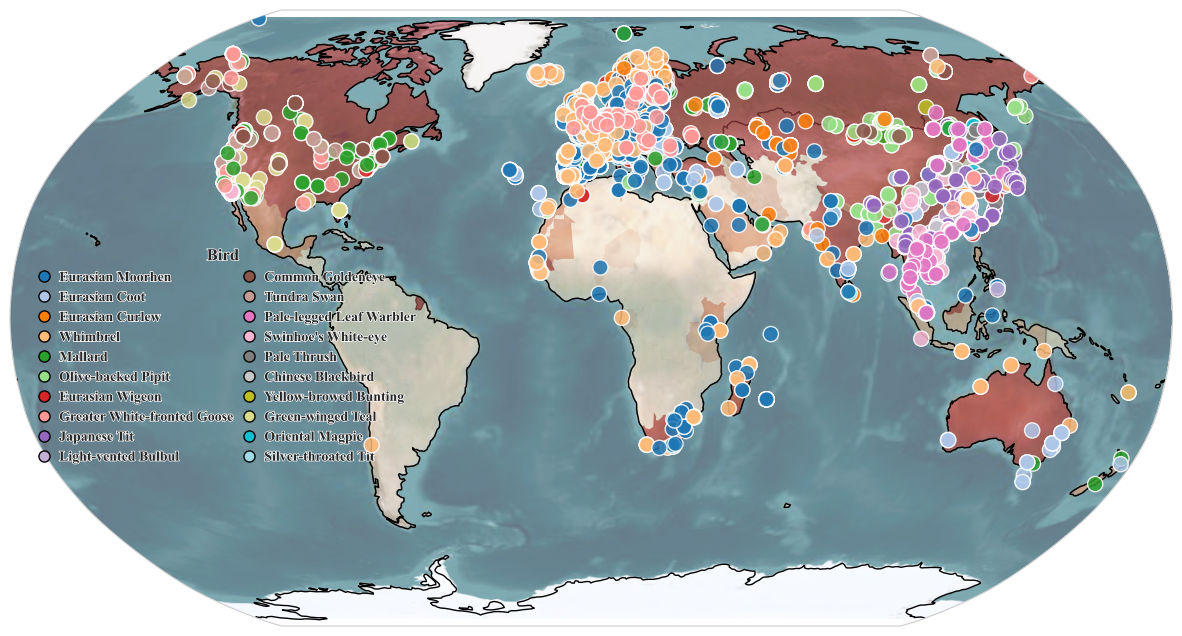

In [17]:
from palettable.tableau import Tableau_20  # 导入 Tableau_20 调色板
import adjustText 
tableau_colors = Tableau_20.mpl_colors  # 提取颜色
cmap =plt.cm.colors.ListedColormap(tableau_colors)

# **统计每个鸟类的数量**
bird_counts = gdf["bird"].dropna().value_counts()

# **按照数量从多到少排序**
sorted_birds = bird_counts.index.tolist()

# **获取唯一鸟类类别及颜色**
unique_birds = sorted_birds
color_map = dict(zip(unique_birds, tableau_colors[:len(unique_birds)]))  # 颜色映射

fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.Robinson()})  
ax.set_global()  # 适应全球视角
ax.coastlines(resolution='110m')
continents.plot( alpha=0.4, color="none", edgecolor='black',ax=ax)
gdf["color"] = gdf["bird"].map(lambda x: color_map.get(x, "#d3d3d3"))


# **绘制数据点**
gdf.plot(
    ax=ax,
    color=gdf["color"],  # **确保颜色匹配**
    markersize=120,
    edgecolor="white",
    alpha=0.85,
    zorder=10
)


# 绘制数据点（或区域）
# gdf.plot(
#     ax=ax,
#     column="bird",      # 按 'cultivation' 列进行着色
#     legend=True,               # 显示图例
#     cmap=cmap,             # 使用黄色-橙色-棕色配色方案
#     markersize=70,             # 数据点大小
#     edgecolor="none"     ,     # 数据点边界颜色
#     alpha=0.6,zorder=10
# )
ctx.add_basemap(ax, crs=df.crs.to_string(), source=ctx.providers.Esri.WorldImagery,alpha=0.6, attribution=False)

plt.rc('legend', fontsize=10)
# 先删除原来的图例
legend = ax.get_legend()
if legend:
    legend.remove()  # **删除原图例**

legend_patches = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color_map[bird], markersize=8, label=bird) 
    for bird in unique_birds
]
# **创建图例**
legend = ax.legend(
    handles=legend_patches,
    title="Bird",
    loc="lower left",
    bbox_to_anchor=(0.01, 0.25),  # **左下角**
    frameon=False,
    fontsize=10,
    ncol=2,  # **确保是两列**
    handletextpad=0.1,  # **缩小符号和文本的间距**
    columnspacing=0.1,  # **缩小列间距**
    borderpad=0.1  # **缩小图例内部填充**
)

# **确保颜色不透明**
for patch in legend_patches:
    patch.set_alpha(1.0)

# **遍历图例文本项并加粗**
for text in legend.get_texts():
    text.set_fontsize(10)
    text.set_weight("bold")
    text.set_path_effects([
        path_effects.Stroke(linewidth=1, foreground="white"),  # **白色描边**
        path_effects.Normal()
    ])

# **处理标题**
title = legend.get_title()
if title:
    title.set_fontsize(12)
    title.set_weight("bold")
    title.set_path_effects([
        path_effects.Stroke(linewidth=1, foreground="white"),
        path_effects.Normal()
    ])
# # legend = ax.get_legend()
# if legend:
#     legend.set_title("Bird", prop={"size": 10, "weight": "bold"})
# if legend:
#     legend.set_bbox_to_anchor((0.3, 0.6))  # **调整位置到左下角**
#     legend.set_frame_on(False)  # **去除背景框**
#     # **修改图例颜色的 alpha**
#     for patch in legend.get_patches():
#         patch.set_alpha(1.0)
# # 遍历图例中的所有文本项
# for text in legend.get_texts():
#     text.set_fontsize(10)  # **设定字体大小**
#     text.set_weight("bold")  # **加粗**
#     text.set_path_effects([
#         path_effects.Stroke(linewidth=1.5, foreground="white"),  # **白色描边**
#         path_effects.Normal()
#     ])
# # **处理标题**
# title = legend.get_title()
# title.set_path_effects([
#     path_effects.Stroke(linewidth=1.5, foreground="white"),  # **白色描边**
#     path_effects.Normal()
# ])



# **绘制 Pie Chart**
for continent, (lon, lat, labels, percentages) in pie_data.items():
    sample_size = continent_sizes.get(continent, 10)

    # **跳过数据点少于 10 的洲**
    if sample_size < 10:
        continue

    # **计算 Pie Chart 大小**
    max_size = max(continent_sizes.values())
    # 根据样本量调节 inset_axes 的大小
    pie_size = 1 + (0.2 * sample_size / max_size)  # 仅作演示
    datan = np.array(percentages, dtype=float)
    datan = datan / datan.sum()

    data_for_plot = np.array(datan*100)

    plot_radarbar_inset(
        data=data_for_plot,
        labels=labels,
        lon=lon,
        lat=lat,
        ax=ax,
        width=pie_size,   # 决定贴图大小
        fontsize=20,
        max_radius=20,
        inner_radius=5,
        bar_color_major="#ffc719",
        bar_color_minor="#00c6d7",
        show_text=True,
        zoom=0.38,addin=False
    )

df.plot(
    ax=ax,
    column="count",  # 按样本点数量着色
    cmap=country_cmap,  # 灰色映射
    linewidth=0,  # **不绘制边界**
    edgecolor="none",
    alpha=0.5,  # 透明度
    legend=False,  # 显示颜色条
    norm=norm  # 归一化颜色
)

    
# 美化 x-tick 和 y-tick
ax.tick_params(axis="both", which="major", labelsize=14, color="gray", length=6, width=1.5)
ax.tick_params(axis="both", which="minor", labelsize=12, color="lightgray", length=4, width=1)

# 自定义格式化坐标轴（将经纬度显示为度）
def format_degree(value, pos):
    return f"{value:.1f}°"

# 添加 xlabel 和 ylabel
ax.set_xlabel("Longitude (°)", fontsize=16, labelpad=20, color="black")
ax.set_ylabel("Latitude (°)", fontsize=16, labelpad=20, color="black")
ax.set_aspect("auto") 

import matplotlib.ticker as mticker

# 美化 x-tick 和 y-tick
ax.tick_params(axis="both", which="major", labelsize=14, color="gray", length=6, width=1.5)
ax.tick_params(axis="both", which="minor", labelsize=12, color="lightgray", length=4, width=1)


plt.savefig("地图.svg", bbox_inches='tight')
plt.savefig("地图.jpg",dpi=500, bbox_inches='tight')
plt.show()

In [66]:
# **获取所有鸟类**
bird_names = bird_counts.index.tolist()  
bird_values = bird_counts.values
# **获取前5种鸟类用于标注**
top5_birds = bird_names[:5]
top5_values = bird_values[:5]
# **所有鸟类的颜色**
color_map = dict(zip(bird_names, tableau_colors[:len(bird_names)]))  
bird_colors = [color_map[bird] for bird in bird_names]  # 获取所有颜色

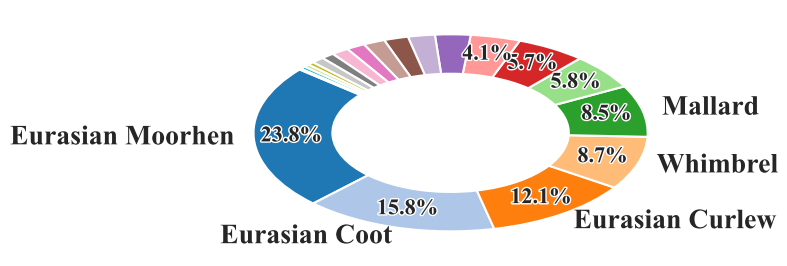

In [83]:
# **创建环形图**
fig, ax = plt.subplots(figsize=(8, 8))

# **绘制环形图**
wedges, texts, autotexts = ax.pie(
    bird_values, 
    labels=['' if bird not in top5_birds else bird for bird in bird_names],  
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',  # 仅显示大于3%的
    colors=bird_colors, 
    startangle=140,
    textprops={'fontsize': 20, 'weight': 'bold'},  # **提高字体大小**
    wedgeprops={'edgecolor': 'w', 'linewidth': 1.5, 'width': 0.4}  # **细化边框**
)

# **美化前5种鸟类的标签**
for i, bird in enumerate(bird_names):
    autotexts[i].set_fontsize(16)
    autotexts[i].set_fontweight('bold')
    autotexts[i].set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='white'),  # **白色描边**
        path_effects.Normal()
    ])

for autotext in autotexts:
    autotext.set_position((autotext.get_position()[0] * 1.35,  # x 坐标调整
                           autotext.get_position()[1] * 1.35))  # y 坐标调整

for text in texts:
    text.set_path_effects([
        path_effects.Stroke(linewidth=1, foreground='white'),
        path_effects.Normal()
    ])


# **去除默认边框**
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# **调整饼图大小**
ax.set_aspect(0.5)  # **增加饼图压缩比例，让它更紧凑**
fig.subplots_adjust(left=0.2, right=0.8, top=0.8, bottom=0.2)  # **减少边距**

# **美化背景**
fig.patch.set_facecolor("white")

# **优化布局**
plt.tight_layout()

# **保存高质量图片**
plt.savefig("bird_species_distribution.svg", bbox_inches='tight', transparent=True)

# **显示图形**
plt.show()


In [41]:
# 批量转换：.适用于多个点
def transform_coords(row):
    return crs.transform_point(row["longitude"], row["latitude"], ccrs.PlateCarree())

# 应用到 DataFrame 并拆分成两个新列
data[["lon_proj", "lat_proj"]] = data.apply(transform_coords, axis=1, result_type="expand")

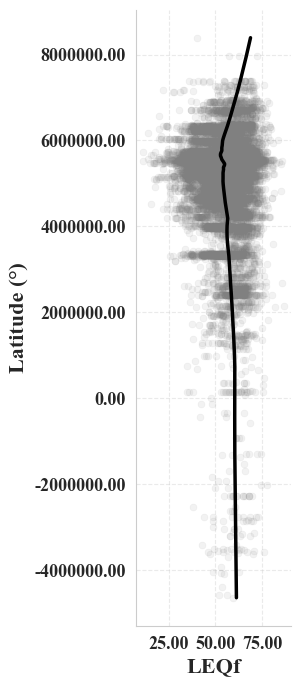

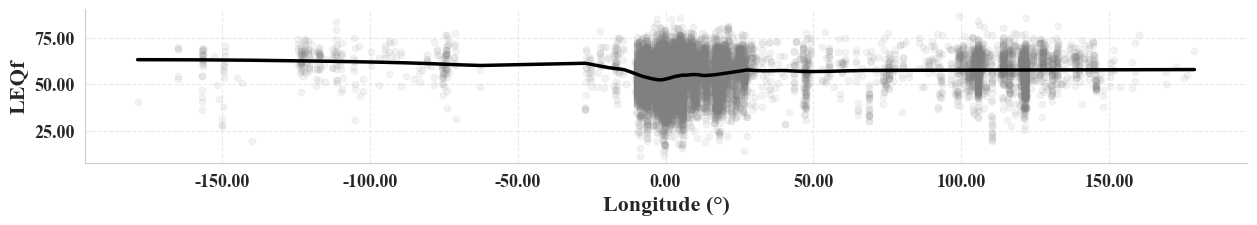

In [134]:

import seaborn as sns
import statsmodels.api as sm

name = 'LEQf'


# **LOWESS 平滑曲线**
def lowess_smooth(x, y, frac=0.3):
    """局部加权回归（LOWESS）平滑数据"""
    lowess = sm.nonparametric.lowess(y, x, frac=frac)
    return lowess[:, 0], lowess[:, 1]


# **绘制 LEQf vs 纬度**
fig, ax = plt.subplots(figsize=(2, 8))

# 散点图
sns.scatterplot(y=data["latitude"], x=data[name], color="gray", alpha=0.1, s=25, edgecolor=None)



# LOWESS 平滑曲线
lat_sorted, leqf_smooth = lowess_smooth(data["latitude"], data[name])
ax.plot(leqf_smooth, lat_sorted, color="black", linewidth=2.5, label="LOWESS Fit")

# **格式优化**
ax.set_xlabel("LEQf", fontsize=16, fontweight="bold")
ax.set_ylabel("Latitude (°)", fontsize=16, fontweight="bold")
ax.spines["top"].set_visible(False)  # 移除顶部边框
ax.spines["right"].set_visible(False)  # 移除右侧边框
# ax.legend(fontsize=14, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
plt.savefig("LEQF纬度.jpg",dpi=500, bbox_inches='tight')

plt.show()

# **绘制 LEQf vs 经度**
fig, ax = plt.subplots(figsize=(15, 2))
# 散点图
sns.scatterplot(x=data["longitude"], y=data[name], color="gray", alpha=0.1, s=25, edgecolor=None)

# LOWESS 平滑曲线
lon_sorted, leqf_smooth = lowess_smooth(data["longitude"], data[name])
ax.plot(lon_sorted, leqf_smooth, color="black", linewidth=2.5, label="LOWESS Fit")

# **格式优化**
ax.set_xlabel("Longitude (°)", fontsize=16, fontweight="bold")
ax.set_ylabel("LEQf", fontsize=16, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.legend(fontsize=14, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))  # Y轴格式化显示两位小数
ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
plt.savefig("LEQF经度.jpg",dpi=500, bbox_inches='tight')

plt.show()

In [16]:
data

,id,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,latitude,...,TFSD,H_Havrda,H_Renyi,H_gamma,H_GiniSimpson,AGI,ROItotal,ROIcover,bird,habitat
0,0,2022-01-16 00:00:00,Eurasian Teal,Anas crecca,XC706499.mp3,XC706499,Irish Wildlife Sounds,Ireland,"Tacumshane, Wexford, County Wexford",52.1853,...,0.000000,0.323276,1.750406,342.933459,0.846384,1.763521,144.0,3.166691,Eurasian Moorhen,Aquatic and Wetland Surface Birds
1,1,2023-12-13 10:03:00,Eurasian Teal,Anas crecca,XC872164.mp3,XC872164,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.478084,0.331455,2.589358,35582.846346,0.942238,1.263552,73.0,3.437754,Eurasian Moorhen,Aquatic and Wetland Surface Birds
2,2,2024-11-04 08:11:00,Eurasian Teal,Anas crecca,XC946313.mp3,XC946313,Sonothèque ADVL,France,"Cabane Vauban (Carolles), Manche, Normandie",48.7443,...,0.364335,0.329500,2.232644,4023.734559,0.916002,1.307255,128.0,9.873588,Eurasian Moorhen,Aquatic and Wetland Surface Birds
3,3,2014-07-13 09:00:00,Eurasian Teal,Anas crecca,XC187090.mp3,XC187090,Albert Lastukhin,Russian Federation,"Novocheboksarsk, gorod Novocheboksarsk, Chuvas...",56.1056,...,0.460048,0.333260,4.210168,24701.050359,0.987338,1.420083,267.0,5.509801,Eurasian Moorhen,Aquatic and Wetland Surface Birds
4,4,2023-12-18 15:03:00,Eurasian Teal,Anas crecca,XC872174.mp3,XC872174,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.476359,0.332782,3.201939,38474.387121,0.972857,1.285792,161.0,4.207794,Eurasian Moorhen,Aquatic and Wetland Surface Birds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,14620,2020-10-04 21:05:00,Greater White-fronted Goose,Anser albifrons,XC592979.mp3,XC592979,Juha Saari,Finland,"Pihlajamäki, Helsinki, Uusimaa",60.2357,...,0.000000,0.332714,3.144461,6733.278040,0.967246,2.038239,278.0,13.252572,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14621,14621,2022-10-02 22:00:00,Greater White-fronted Goose,Anser albifrons,XC753535.mp3,XC753535,Uku Paal,Estonia,"Tartu, Tartu City, Tartu maakond",58.3752,...,0.000000,0.332871,3.289931,10339.811767,0.968750,1.265332,397.0,4.669571,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14622,14622,2008-02-17 19:05:00,Greater White-fronted Goose,Anser albifrons,XC280889.mp3,XC280889,Peter Boesman,Belgium,"Uitkerkse polders, West-Vlaanderen",51.2950,...,0.000000,0.330864,2.452579,880.761415,0.924076,4.589344,89.0,4.272296,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14623,14623,2021-11-23 01:36:00,Greater White-fronted Goose,Anser albifrons,XC718649.mp3,XC718649,Chèvremont Fabian,Belgium,"Fléron, Liège, Wallonie",50.6041,...,0.387644,0.331772,2.681686,16106.852922,0.948817,1.245774,110.0,1.291541,Greater White-fronted Goose,Aquatic and Wetland Surface Birds


In [17]:
data

,id,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,latitude,...,TFSD,H_Havrda,H_Renyi,H_gamma,H_GiniSimpson,AGI,ROItotal,ROIcover,bird,habitat
0,0,2022-01-16 00:00:00,Eurasian Teal,Anas crecca,XC706499.mp3,XC706499,Irish Wildlife Sounds,Ireland,"Tacumshane, Wexford, County Wexford",52.1853,...,0.000000,0.323276,1.750406,342.933459,0.846384,1.763521,144.0,3.166691,Eurasian Moorhen,Aquatic and Wetland Surface Birds
1,1,2023-12-13 10:03:00,Eurasian Teal,Anas crecca,XC872164.mp3,XC872164,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.478084,0.331455,2.589358,35582.846346,0.942238,1.263552,73.0,3.437754,Eurasian Moorhen,Aquatic and Wetland Surface Birds
2,2,2024-11-04 08:11:00,Eurasian Teal,Anas crecca,XC946313.mp3,XC946313,Sonothèque ADVL,France,"Cabane Vauban (Carolles), Manche, Normandie",48.7443,...,0.364335,0.329500,2.232644,4023.734559,0.916002,1.307255,128.0,9.873588,Eurasian Moorhen,Aquatic and Wetland Surface Birds
3,3,2014-07-13 09:00:00,Eurasian Teal,Anas crecca,XC187090.mp3,XC187090,Albert Lastukhin,Russian Federation,"Novocheboksarsk, gorod Novocheboksarsk, Chuvas...",56.1056,...,0.460048,0.333260,4.210168,24701.050359,0.987338,1.420083,267.0,5.509801,Eurasian Moorhen,Aquatic and Wetland Surface Birds
4,4,2023-12-18 15:03:00,Eurasian Teal,Anas crecca,XC872174.mp3,XC872174,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.476359,0.332782,3.201939,38474.387121,0.972857,1.285792,161.0,4.207794,Eurasian Moorhen,Aquatic and Wetland Surface Birds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,14620,2020-10-04 21:05:00,Greater White-fronted Goose,Anser albifrons,XC592979.mp3,XC592979,Juha Saari,Finland,"Pihlajamäki, Helsinki, Uusimaa",60.2357,...,0.000000,0.332714,3.144461,6733.278040,0.967246,2.038239,278.0,13.252572,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14621,14621,2022-10-02 22:00:00,Greater White-fronted Goose,Anser albifrons,XC753535.mp3,XC753535,Uku Paal,Estonia,"Tartu, Tartu City, Tartu maakond",58.3752,...,0.000000,0.332871,3.289931,10339.811767,0.968750,1.265332,397.0,4.669571,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14622,14622,2008-02-17 19:05:00,Greater White-fronted Goose,Anser albifrons,XC280889.mp3,XC280889,Peter Boesman,Belgium,"Uitkerkse polders, West-Vlaanderen",51.2950,...,0.000000,0.330864,2.452579,880.761415,0.924076,4.589344,89.0,4.272296,Greater White-fronted Goose,Aquatic and Wetland Surface Birds
14623,14623,2021-11-23 01:36:00,Greater White-fronted Goose,Anser albifrons,XC718649.mp3,XC718649,Chèvremont Fabian,Belgium,"Fléron, Liège, Wallonie",50.6041,...,0.387644,0.331772,2.681686,16106.852922,0.948817,1.245774,110.0,1.291541,Greater White-fronted Goose,Aquatic and Wetland Surface Birds


In [18]:
gdf

,id,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,latitude,...,H_GiniSimpson,AGI,ROItotal,ROIcover,bird,habitat,geometry,ADMIN,index_right,CONTINENT
0,0,2022-01-16 00:00:00,Eurasian Teal,Anas crecca,XC706499.mp3,XC706499,Irish Wildlife Sounds,Ireland,"Tacumshane, Wexford, County Wexford",52.1853,...,0.846384,1.763521,144.0,3.166691,Eurasian Moorhen,Aquatic and Wetland Surface Birds,POINT (-516417.654 5551919.771),NaN,NaN,NaN
1,1,2023-12-13 10:03:00,Eurasian Teal,Anas crecca,XC872164.mp3,XC872164,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.942238,1.263552,73.0,3.437754,Eurasian Moorhen,Aquatic and Wetland Surface Birds,POINT (816811.367 5140854.762),Germany,2.0,Europe
2,2,2024-11-04 08:11:00,Eurasian Teal,Anas crecca,XC946313.mp3,XC946313,Sonothèque ADVL,France,"Cabane Vauban (Carolles), Manche, Normandie",48.7443,...,0.916002,1.307255,128.0,9.873588,Eurasian Moorhen,Aquatic and Wetland Surface Birds,POINT (-129786.482 5196676.571),France,2.0,Europe
3,3,2014-07-13 09:00:00,Eurasian Teal,Anas crecca,XC187090.mp3,XC187090,Albert Lastukhin,Russian Federation,"Novocheboksarsk, gorod Novocheboksarsk, Chuvas...",56.1056,...,0.987338,1.420083,267.0,5.509801,Eurasian Moorhen,Aquatic and Wetland Surface Birds,POINT (3715258.32 5949718.643),Russia,2.0,Europe
4,4,2023-12-18 15:03:00,Eurasian Teal,Anas crecca,XC872174.mp3,XC872174,Johannes Dag Mayer,Germany,"Suedsee, Laupheim, Biberach, Tübingen, Baden-W...",48.2078,...,0.972857,1.285792,161.0,4.207794,Eurasian Moorhen,Aquatic and Wetland Surface Birds,POINT (816811.367 5140854.762),Germany,2.0,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,14620,2020-10-04 21:05:00,Greater White-fronted Goose,Anser albifrons,XC592979.mp3,XC592979,Juha Saari,Finland,"Pihlajamäki, Helsinki, Uusimaa",60.2357,...,0.967246,2.038239,278.0,13.252572,Greater White-fronted Goose,Aquatic and Wetland Surface Birds,POINT (1882455.483 6359101.863),Finland,2.0,Europe
14621,14621,2022-10-02 22:00:00,Greater White-fronted Goose,Anser albifrons,XC753535.mp3,XC753535,Uku Paal,Estonia,"Tartu, Tartu City, Tartu maakond",58.3752,...,0.968750,1.265332,397.0,4.669571,Greater White-fronted Goose,Aquatic and Wetland Surface Birds,POINT (2044335.576 6176034.181),Estonia,2.0,Europe
14622,14622,2008-02-17 19:05:00,Greater White-fronted Goose,Anser albifrons,XC280889.mp3,XC280889,Peter Boesman,Belgium,"Uitkerkse polders, West-Vlaanderen",51.2950,...,0.924076,4.589344,89.0,4.272296,Greater White-fronted Goose,Aquatic and Wetland Surface Birds,POINT (253042.529 5460502.331),Belgium,2.0,Europe
14623,14623,2021-11-23 01:36:00,Greater White-fronted Goose,Anser albifrons,XC718649.mp3,XC718649,Chèvremont Fabian,Belgium,"Fléron, Liège, Wallonie",50.6041,...,0.948817,1.245774,110.0,1.291541,Greater White-fronted Goose,Aquatic and Wetland Surface Birds,POINT (462444.418 5389311.903),Belgium,2.0,Europe
